# Annotation in Scanpy

In [1]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [2]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.3] # This takes a while per res

2025-01-27 11:03:43,592 - INFO - Plate variable detected: plate1
2025-01-27 11:03:43,594 - INFO - Processing plate: plate1



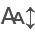

2025-01-27 11:03:43,615 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-27 11:03:43,616 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-27 11:03:43,616 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-27 11:03:43,617 - INFO - Scanpy directory exists: True
2025-01-27 11:03:43,617 - INFO - Sheets directory: /Users/darren/Desktop/eQTL_study_2025/resources/sheets/
2025-01-27 11:03:43,618 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-27 11:03:43,619 - INFO - Loading data ...


(5225, 2000)

In [3]:
# Initialize the environment and get all paths and logger
logger, root_dir, sheets_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")
adata = sc.read(scanpy_dir + f'adata_clusters.h5ad')
adata.shape

In [4]:
# Violin plots of gene expression

2025-01-27 11:03:43,892 - INFO - Plot Violin ...


Genes not found in dataset for gene set Nowak_fig4: C1QC, TTR, CRYAB, NEUROG1, PIF1, SST, LINCO1305, TAC3, SLN
Genes not found in dataset for gene set Poulio_fig1c: CCL3, AIF1
Genes not found in dataset for gene set Camer_pfc: SST
Genes not found in dataset for gene set Oligo: MOG, MAG
Genes not found in dataset for gene set Opc: NG2
Genes not found in dataset for gene set Ipc: TBR2
Genes not found in dataset for gene set Smallpop: KCNJ8, COLA1, TM4SF1, CYTL1, MGP
Genes not found in dataset for gene set General: SST, PVALB, VIP, C1QB, PDGRFA
Generating plots for resolution: default
Plotting gene set Nowak_fig4 with 29 genes out of 38 provided.
Plotting gene set Poulio_fig1c with 34 genes out of 36 provided.
Plotting gene set Camer_pfc with 14 genes out of 15 provided.
Plotting gene set ExN with 8 genes out of 8 provided.
Plotting gene set InN with 9 genes out of 9 provided.
Plotting gene set Oligo with 5 genes out of 7 provided.
Plotting gene set Opc with 5 genes out of 6 provided.
Plo

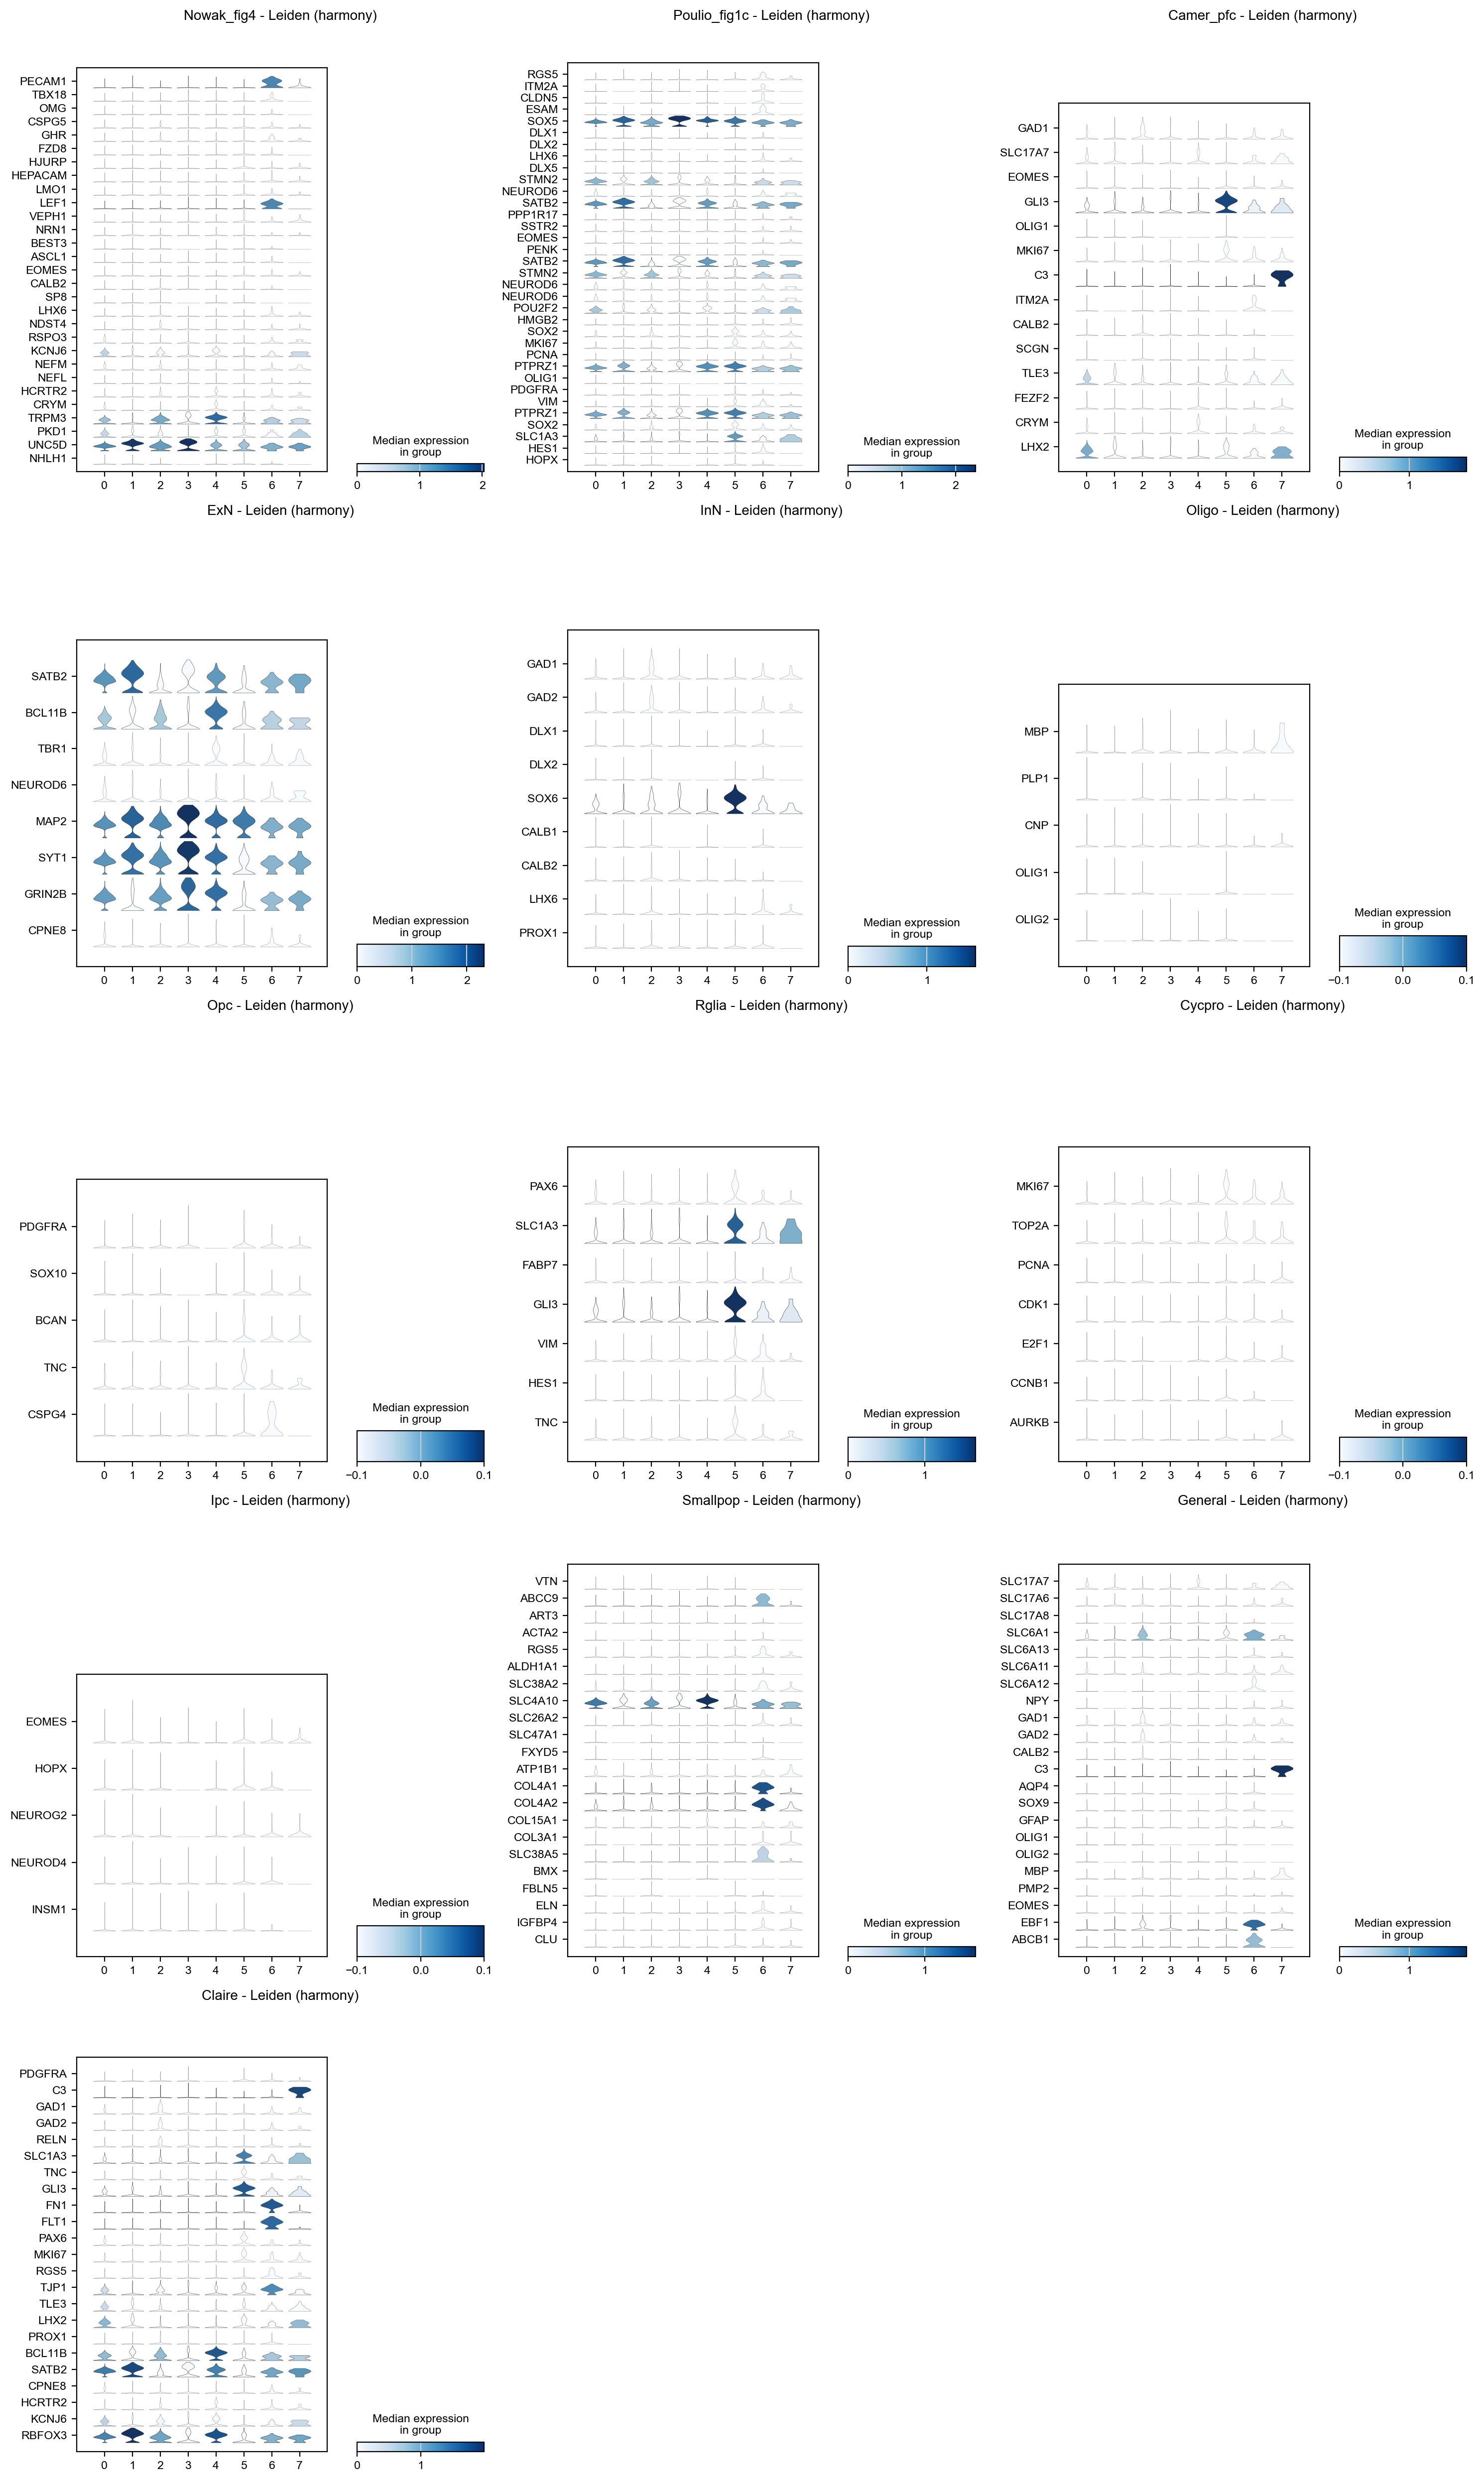

In [5]:
# Violin plots
logger.info("Plot Violin ...")
gene_sets = [("Nowak_fig4", Nowakowski_Fig4A_genes), 
             ("Poulio_fig1c", Pouliodakis_fig1c_genes), 
             ("Camer_PFC", pfc_features), 
             ("ExNs", exN_genes), 
             ("InNs", inN_genes),
                ("Oligos", olig_genes),
                ("OPCs", opc_genes),
                ("RGs", r_glia_genes),
                ("Cyc-Pro", cyc_pro_genes),
                ("IPC", ipc_genes),
                ("Small-Pops", small_populations),
                ("General", general_genes),
                ("Claire", claire_genes)]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden_harmony", 
    resolutions=resolutions, 
    clustering_algorithm="Leiden (harmony)")
plt.show()  # Display the figure

In [6]:
# UMAP
obs_columns = ['sublibrary', 'plate']
plot_umap_grid(adata, obs_columns, grid_size=(2, 2), figsize=(10, 8), save_path=None)


NameError: name 'obs_columns' is not defined